#### Notebook Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255/voice-command-assistant")


for p in [
    PROJECT_ROOT/"notebooks",
    PROJECT_ROOT/"src",
    PROJECT_ROOT/"data/raw",
    PROJECT_ROOT/"data/processed",
    PROJECT_ROOT/"data/cache",
    PROJECT_ROOT/"models",
    PROJECT_ROOT/"results/figures",
    PROJECT_ROOT/"results/logs",
    PROJECT_ROOT/"reports",
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(PROJECT_ROOT/"data/cache/hf_home")
os.environ["HF_DATASETS_CACHE"] = str(PROJECT_ROOT/"data/cache/hf_datasets")
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT/"data/cache/transformers")

!pip install datasets==2.14.7

print("PROJECT_ROOT:", PROJECT_ROOT)
print("HF_HOME:", os.environ["HF_HOME"])

Mounted at /content/drive
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multipr

# 1. Data ingestion and Verification

### Imports + datasett

In [2]:
from datasets import load_dataset

ds = load_dataset("google/speech_commands", "v0.02")

ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/84848 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9982 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4890 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 84848
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 9982
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 4890
    })
})

#### Vis splits + størrelser

In [3]:
from datasets import DatasetDict
import pandas as pd

assert isinstance(ds, DatasetDict), f"Expected DatasetDict, got {type(ds)}"

split_sizes = {split: len(ds[split]) for split in ds.keys()}
pd.DataFrame({"split": list(split_sizes.keys()), "n": list(split_sizes.values())}).sort_values("split")

,split,n
2,test,4890
0,train,84848
1,validation,9982


#### Inspect schema / features per split

In [4]:
for split in ds.keys():
    print(f"\n=== Split: {split} ===")
    print(ds[split])
    print("Features:", ds[split].features)


=== Split: train ===
Dataset({
    features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
    num_rows: 84848
})
Features: {'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'label': ClassLabel(names=['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', 'backward', 'forward', 'follow', 'learn', 'visual', '_silence_'], id=None), 'is_unknown': Value(dtype='bool', id=None), 'speaker_id': Value(dtype='string', id=None), 'utterance_id': Value(dtype='int8', id=None)}

=== Split: validation ===
Dataset({
    features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
    num_rows: 9982
})
Features: {'file': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 

#### Peek på rader (kolonner) + audio-structure

In [5]:
example = ds[list(ds.keys())[0]][0]
example.keys(), example

(dict_keys(['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id']),
 {'file': 'backward/2356b88d_nohash_0.wav',
  'audio': {'path': 'backward/2356b88d_nohash_0.wav',
   'array': array([ 0.        ,  0.        ,  0.        , ..., -0.00012207,
          -0.00015259, -0.00012207]),
   'sampling_rate': 16000},
  'label': 30,
  'is_unknown': True,
  'speaker_id': '2356b88d',
  'utterance_id': 0})

#### Unike labels (og evt speaker_id) per split

In [6]:
def get_unique_values(split, col, max_show=30):
    if col not in ds[split].column_names:
        return None
    vals = ds[split].unique(col)
    return vals, len(vals), vals[:max_show]

label_col_candidates = ["label", "labels", "command", "word"]
speaker_col_candidates = ["speaker_id", "speaker", "speakerid", "client_id", "user_id"]

splits = list(ds.keys())
cols = ds[splits[0]].column_names
print("Column names:", cols)

label_col = next((c for c in label_col_candidates if c in cols), None)
speaker_col = next((c for c in speaker_col_candidates if c in cols), None)

print("Detected label_col:", label_col)
print("Detected speaker_col:", speaker_col)

if label_col:
    for split in splits:
        vals, n_vals, preview = get_unique_values(split, label_col)
        print(f"{split}: {n_vals} unique labels. Preview: {preview}")
else:
    print("⚠️ Fant ikke label-kolonne automatisk. Sjekk column_names over og sett label_col manuelt.")

if speaker_col:
    for split in splits:
        vals, n_vals, preview = get_unique_values(split, speaker_col)
        print(f"{split}: {n_vals} unique speakers. Preview: {preview[:10]}")
else:
    print("ℹ️ Ingen speaker_id-kolonne oppdaget (kan fortsatt ligge i path/filename).")

Column names: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id']
Detected label_col: label
Detected speaker_col: speaker_id
train: 36 unique labels. Preview: [30, 20, 21, 22, 23, 3, 18, 15, 32, 31, 14, 9, 24, 25, 33, 4, 26, 19, 1, 7, 6, 11, 5, 17, 27, 35, 16, 8, 13, 28]
validation: 36 unique labels. Preview: [30, 20, 21, 22, 23, 3, 18, 15, 32, 31, 14, 9, 24, 25, 33, 4, 26, 19, 1, 7, 6, 11, 5, 17, 27, 35, 16, 8, 13, 28]
test: 36 unique labels. Preview: [30, 20, 21, 22, 23, 3, 18, 15, 32, 31, 14, 9, 24, 25, 33, 4, 26, 19, 1, 7, 6, 11, 5, 17, 27, 35, 16, 8, 13, 28]
train: 2113 unique speakers. Preview: ['2356b88d', '3291330e', 'b91b718c', '85851131', '244cc3a5', '2927c601', '18e910f4', '9151f184', '86f3558f', 'ef3367d9']
validation: 257 unique speakers. Preview: ['0d82fd99', '4e6902d0', 'ef77b778', 'ce0cb033', '30276d03', 'ff2b842e', '1e02ffc5', 'f822b9bf', '73f20b00', '856eb138']
test: 240 unique speakers. Preview: ['a6f2fd71', '8fe67225', 'f2e59fea', '87070229', '517

#### Sjekk audio-kolonne (hvilken heter den?)

In [7]:
audio_col_candidates = ["audio", "speech", "input_values", "wav"]
audio_col = next((c for c in audio_col_candidates if c in cols), None)
print("Detected audio_col:", audio_col)

if audio_col:
    a = ds[splits[0]][0][audio_col]
    print(type(a))
    print(a)
else:
    print("⚠️ Fant ingen åpenbar audio-kolonne. Sjekk example over og sett audio_col manuelt.")

Detected audio_col: audio
<class 'dict'>
{'path': 'backward/2356b88d_nohash_0.wav', 'array': array([ 0.        ,  0.        ,  0.        , ..., -0.00012207,
       -0.00015259, -0.00012207]), 'sampling_rate': 16000}


## 2. Audio verification (sampling rate, duration, sanity playback)
Mål:
- Verifisere at sampling rate er konsistent (forventet 16 kHz).
- Analysere varighetsdistribusjon (forventet rundt 1 sekund).
- Gjøre sanity check: spille av noen eksempler.

#### Sjekk sampling rate på et random utvalg

In [8]:
import numpy as np
import pandas as pd

audio_col = "audio"
splits = list(ds.keys())

def sample_sampling_rates(split, n=200, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)
    srs = [ds[split][int(i)][audio_col]["sampling_rate"] for i in idx]
    return pd.Series(srs).value_counts().sort_index()

for split in splits:
    print(f"\n=== {split} sampling_rate counts (sample) ===")
    display(sample_sampling_rates(split, n=300))


=== train sampling_rate counts (sample) ===


,count
16000,300



=== validation sampling_rate counts (sample) ===


,count
16000,300



=== test sampling_rate counts (sample) ===


,count
16000,300


#### Beregn varigheter (sekunder) på et utvalg og plott histogram

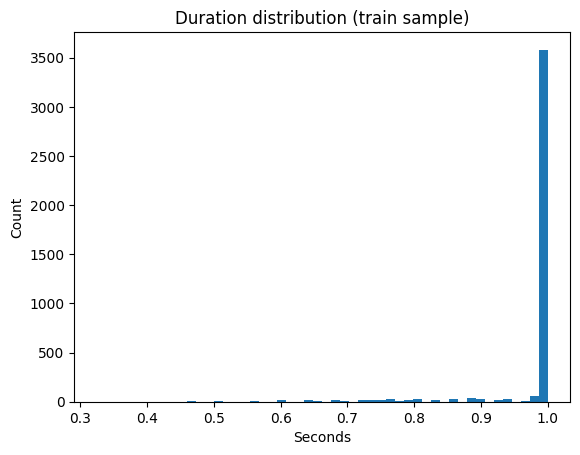

Duration summary (train sample):
count    4000.000000
mean        0.980093
std         0.072463
min         0.325062
1%          0.640000
5%          0.810688
50%         1.000000
95%         1.000000
99%         1.000000
max         1.000000
dtype: float64


In [9]:
import matplotlib.pyplot as plt

def sample_durations(split, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)
    durs = []
    for i in idx:
        ex = ds[split][int(i)][audio_col]
        arr = ex["array"]
        sr = ex["sampling_rate"]
        durs.append(len(arr) / sr)
    return np.array(durs)

dur_train = sample_durations("train", n=4000, seed=123)

plt.figure()
plt.hist(dur_train, bins=50)
plt.title("Duration distribution (train sample)")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

print("Duration summary (train sample):")
print(pd.Series(dur_train).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

#### Plott waveform + spill av 3 tilfeldige eksempler

Split=train idx=72173 file=two/0474c92a_nohash_1.wav label=12 is_unknown=True speaker_id=0474c92a sr=16000 n_samples=16000 dur=1.000s


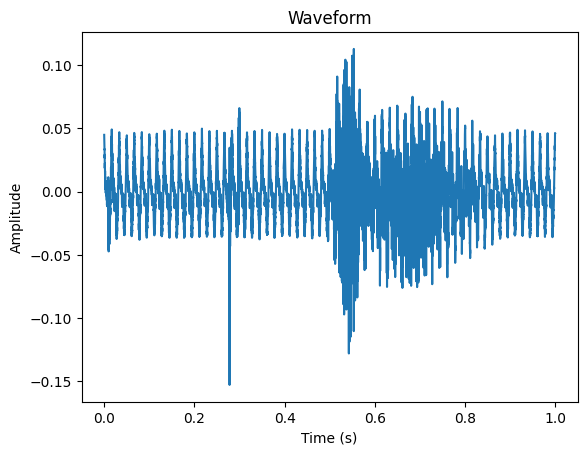

Split=train idx=54044 file=seven/54ad8f22_nohash_3.wav label=17 is_unknown=True speaker_id=54ad8f22 sr=16000 n_samples=16000 dur=1.000s


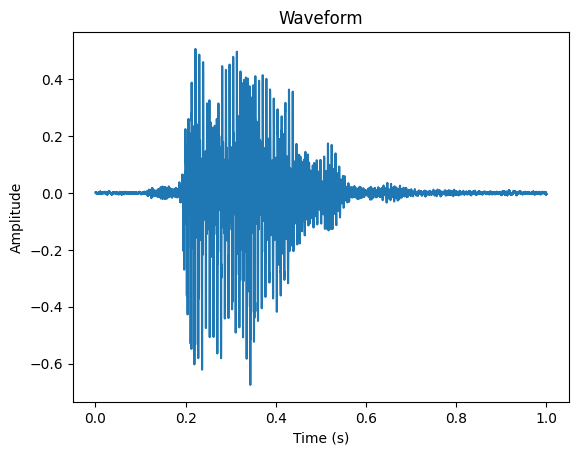

Split=train idx=43368 file=off/28ed6bc9_nohash_3.wav label=7 is_unknown=False speaker_id=28ed6bc9 sr=16000 n_samples=16000 dur=1.000s


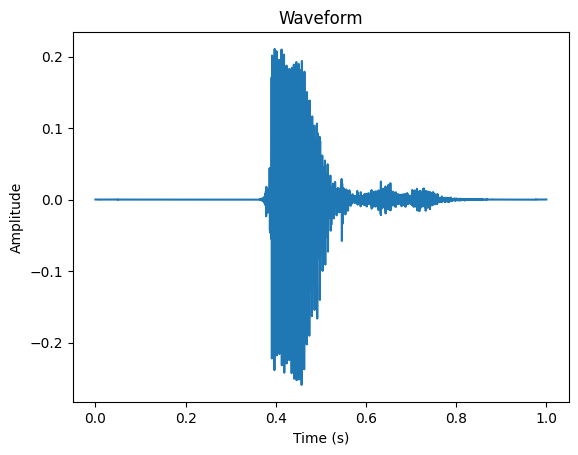

In [10]:
from IPython.display import Audio, display

def show_waveform_and_play(split, idx):
    ex = ds[split][idx]
    a = ex[audio_col]
    arr, sr = a["array"], a["sampling_rate"]
    f = ex["file"]
    label = ex["label"]
    is_unk = ex["is_unknown"]
    speaker = ex["speaker_id"]

    print(f"Split={split} idx={idx} file={f} label={label} is_unknown={is_unk} speaker_id={speaker} sr={sr} n_samples={len(arr)} dur={len(arr)/sr:.3f}s")

    t = np.arange(len(arr)) / sr
    plt.figure()
    plt.plot(t, arr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    display(Audio(arr, rate=sr))

rng = np.random.default_rng(0)
for _ in range(3):
    idx = int(rng.integers(0, len(ds["train"])))
    show_waveform_and_play("train", idx)

#### Lag og plott mel-spectrogram for ett eksempel

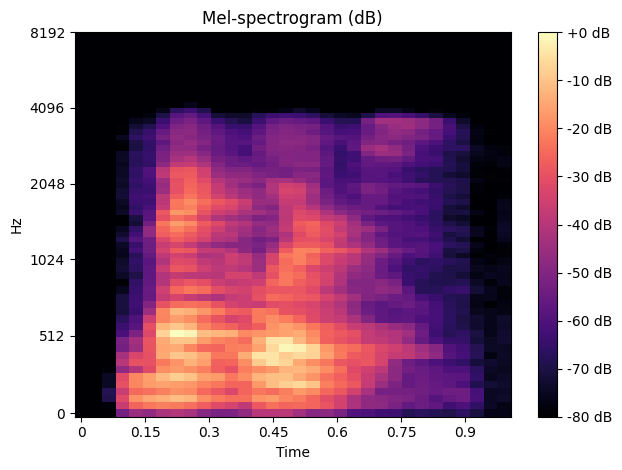

In [11]:
import librosa
import librosa.display

def plot_mel_spectrogram(split, idx, n_mels=64):
    ex = ds[split][idx]
    a = ex[audio_col]
    y, sr = a["array"], a["sampling_rate"]

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=sr/2)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure()
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
    plt.title("Mel-spectrogram (dB)")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

plot_mel_spectrogram("train", idx=0, n_mels=64)

## 3. Label mapping (target space definition)

Goal:
Reduce 36 original commands to:
- up
- down
- left
- right
- unknown
- silence (to be generated later)

All other commands are mapped to "unknown".

#### Finn label-navn fra dataset

In [12]:
label_feature = ds["train"].features["label"]
label_names = label_feature.names

print("Number of original labels:", len(label_names))
print(label_names)

Number of original labels: 36
['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', 'backward', 'forward', 'follow', 'learn', 'visual', '_silence_']


#### Finn indeksene til våre fire kommandoer

In [13]:
target_commands = ["up", "down", "left", "right"]

command_to_index = {name: label_names.index(name) for name in target_commands}
print("Original label indices for target commands:")
print(command_to_index)

Original label indices for target commands:
{'up': 2, 'down': 3, 'left': 4, 'right': 5}


#### Definer target-mapping

In [14]:
TARGET_LABELS = ["up", "down", "left", "right", "unknown", "silence"]
target_to_id = {name: i for i, name in enumerate(TARGET_LABELS)}

def map_to_target(example):
    original_label_id = example["label"]
    original_label_name = label_names[original_label_id]

    if original_label_name in target_commands:
        target_label = original_label_name
    else:
        target_label = "unknown"

    example["target_label"] = target_label
    example["target_id"] = target_to_id[target_label]

    return example

#### Apply mapping

In [15]:
ds_mapped = ds.map(map_to_target)

Map:   0%|          | 0/84848 [00:00<?, ? examples/s]

Map:   0%|          | 0/9982 [00:00<?, ? examples/s]

Map:   0%|          | 0/4890 [00:00<?, ? examples/s]

#### Sjekk class distribution (train)

In [16]:
import pandas as pd

train_targets = ds_mapped["train"]["target_label"]
pd.Series(train_targets).value_counts()

,count
unknown,72710
down,3134
left,3037
right,3019
up,2948


## 4. Class distribution & imbalance (after target mapping)

We map 36 original labels to:
- 4-class: {up, down, left, right}
- 5-class: {up, down, left, right, unknown}
Silence will be generated later for the deployment setting.

Goal:
- Quantify class imbalance.
- Save a label histogram figure for the report.
- Decide training strategy for the 5-class setting (downsampling / class weights / focal loss).

#### Counts + percentages (train/val/test)

In [17]:
def split_distribution(ds_mapped, split):
    vc = pd.Series(ds_mapped[split]["target_label"]).value_counts()
    pct = (vc / vc.sum() * 100).round(2)
    out = pd.DataFrame({"count": vc, "percent": pct})
    return out

for split in ["train", "validation", "test"]:
    print(f"\n=== {split.upper()} target_label distribution ===")
    display(split_distribution(ds_mapped, split))


=== TRAIN target_label distribution ===


,count,percent
unknown,72710,85.69
down,3134,3.69
left,3037,3.58
right,3019,3.56
up,2948,3.47



=== VALIDATION target_label distribution ===


,count,percent
unknown,8540,85.55
down,377,3.78
right,363,3.64
left,352,3.53
up,350,3.51



=== TEST target_label distribution ===


,count,percent
unknown,3251,66.48
up,425,8.69
left,412,8.43
down,406,8.30
right,396,8.10


#### Plot: label histogram (train) + save to Drive

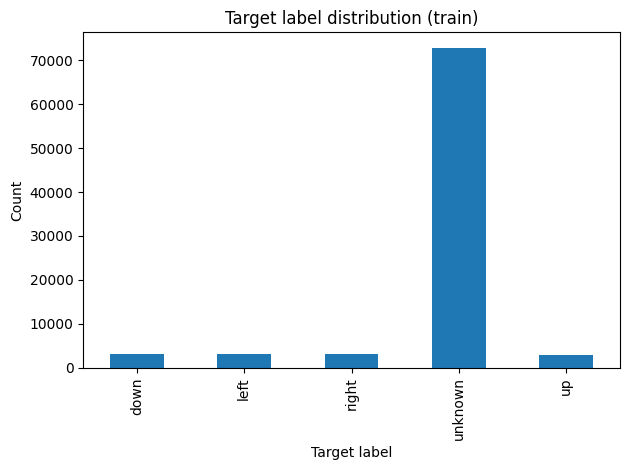

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/label_distribution_train.png


In [19]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = PROJECT_ROOT / "results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

train_vc = pd.Series(ds_mapped["train"]["target_label"]).value_counts()

plt.figure()
train_vc.sort_index().plot(kind="bar")
plt.title("Target label distribution (train)")
plt.xlabel("Target label")
plt.ylabel("Count")
plt.tight_layout()

out_path = fig_dir / "label_distribution_train.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved:", out_path)

#### Definer 4-class og 5-class datasett-views

In [20]:
FOUR_CLASS = {"up", "down", "left", "right"}
FIVE_CLASS = {"up", "down", "left", "right", "unknown"}

def filter_by_targets(dataset, allowed):
    return dataset.filter(lambda x: x["target_label"] in allowed)

ds_4 = {split: filter_by_targets(ds_mapped[split], FOUR_CLASS) for split in ds_mapped.keys()}
ds_5 = {split: filter_by_targets(ds_mapped[split], FIVE_CLASS) for split in ds_mapped.keys()}

print("4-class sizes:", {k: len(v) for k, v in ds_4.items()})
print("5-class sizes:", {k: len(v) for k, v in ds_5.items()})

Filter:   0%|          | 0/84848 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9982 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4890 [00:00<?, ? examples/s]

Filter:   0%|          | 0/84848 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9982 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4890 [00:00<?, ? examples/s]

4-class sizes: {'train': 12138, 'validation': 1442, 'test': 1639}
5-class sizes: {'train': 84848, 'validation': 9982, 'test': 4890}


## 5. Split strategy & data leakage verification

We use the predefined HuggingFace train/validation/test splits.

Goals:
- Verify that speakers do not overlap across splits (avoid speaker leakage).
- Justify why we keep the original splits.
- Lock the split strategy for all experiments.

#### Check speaker overlap across splits

In [21]:
def get_speakers(split):
    return set(ds_mapped[split]["speaker_id"])

train_speakers = get_speakers("train")
val_speakers = get_speakers("validation")
test_speakers = get_speakers("test")

print("Unique speakers:")
print("Train:", len(train_speakers))
print("Validation:", len(val_speakers))
print("Test:", len(test_speakers))

print("\nOverlap checks:")
print("Train ∩ Validation:", len(train_speakers & val_speakers))
print("Train ∩ Test:", len(train_speakers & test_speakers))
print("Validation ∩ Test:", len(val_speakers & test_speakers))

Unique speakers:
Train: 2113
Validation: 257
Test: 240

Overlap checks:
Train ∩ Validation: 1
Train ∩ Test: 1
Validation ∩ Test: 1


#### Check class balance consistency across splits

In [22]:
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()} distribution (percent):")
    pct = split_distribution(ds_mapped, split)["percent"]
    print(pct)


TRAIN distribution (percent):
unknown    85.69
down        3.69
left        3.58
right       3.56
up          3.47
Name: percent, dtype: float64

VALIDATION distribution (percent):
unknown    85.55
down        3.78
right       3.64
left        3.53
up          3.51
Name: percent, dtype: float64

TEST distribution (percent):
unknown    66.48
up          8.69
left        8.43
down        8.30
right       8.10
Name: percent, dtype: float64


## 6. Create reproducible dataset index

Goal:
Create a single index file (index.csv) containing metadata for all samples.

Columns:
- file
- split
- speaker_id
- original_label
- target_label
- target_id
- is_unknown

The index ensures:
- Reproducibility
- Clean separation between data and code
- Easier training pipelines in later notebooks

In [23]:
import pandas as pd

rows = []

for split in ds_mapped.keys():
    dataset = ds_mapped[split]

    for i in range(len(dataset)):
        ex = dataset[i]

        rows.append({
            "file": ex["file"],
            "split": split,
            "speaker_id": ex["speaker_id"],
            "original_label_id": ex["label"],
            "original_label_name": label_names[ex["label"]],
            "target_label": ex["target_label"],
            "target_id": ex["target_id"],
            "is_unknown": ex["is_unknown"],
        })

index_df = pd.DataFrame(rows)

print("Index shape:", index_df.shape)
index_df.head()

Index shape: (99720, 8)


,file,split,speaker_id,original_label_id,original_label_name,target_label,target_id,is_unknown
0,backward/2356b88d_nohash_0.wav,train,2356b88d,30,backward,unknown,4,True
1,backward/3291330e_nohash_3.wav,train,3291330e,30,backward,unknown,4,True
2,backward/b91b718c_nohash_3.wav,train,b91b718c,30,backward,unknown,4,True
3,backward/85851131_nohash_1.wav,train,85851131,30,backward,unknown,4,True
4,backward/244cc3a5_nohash_0.wav,train,244cc3a5,30,backward,unknown,4,True


#### Basic sanity checks

In [24]:
print("Rows per split:")
print(index_df["split"].value_counts())

print("\nTarget distribution (global):")
print(index_df["target_label"].value_counts())

print("\nUnique speakers:", index_df["speaker_id"].nunique())

Rows per split:
split
train         84848
validation     9982
test           4890
Name: count, dtype: int64

Target distribution (global):
target_label
unknown    84501
down        3917
left        3801
right       3778
up          3723
Name: count, dtype: int64

Unique speakers: 2607


#### Lagre til Drive

In [26]:
index_path = PROJECT_ROOT / "data" / "processed" / "index.csv"
index_df.to_csv(index_path, index=False)

print("Saved index to:", index_path)

Saved index to: /content/drive/MyDrive/DAT255/voice-command-assistant/data/processed/index.csv


In [27]:
index_4 = index_df[index_df["target_label"].isin(FOUR_CLASS)]
index_4_path = PROJECT_ROOT / "data" / "processed" / "index_4class.csv"
index_4.to_csv(index_4_path, index=False)

print("Saved 4-class index to:", index_4_path)
print("4-class size:", len(index_4))

Saved 4-class index to: /content/drive/MyDrive/DAT255/voice-command-assistant/data/processed/index_4class.csv
4-class size: 15219
